In [143]:
from qiskit import *
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt


In [144]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
N          = 500    # Number of generated points
TEST_SIZE  = 0.2     # Fraction used for test set
SEED       = 1     # Random seed (data split & optimizer init)

# Model
RC         = 4       # Number of circuit layers

# Optimization
MAXITER    = 300     # COBYLA max iterations

# Simulation
USE_NOISE  = False   # True  → noisy AerSimulator  |  False → exact Statevector
NOISE_RATE = 0.005   # Depolarizing error rate per gate (USE_NOISE=True only)
SHOTS      = 1024    # Number of shots              (USE_NOISE=True only)

# ──────────────────────────────────────────────────────────────────────────────


# Data generation

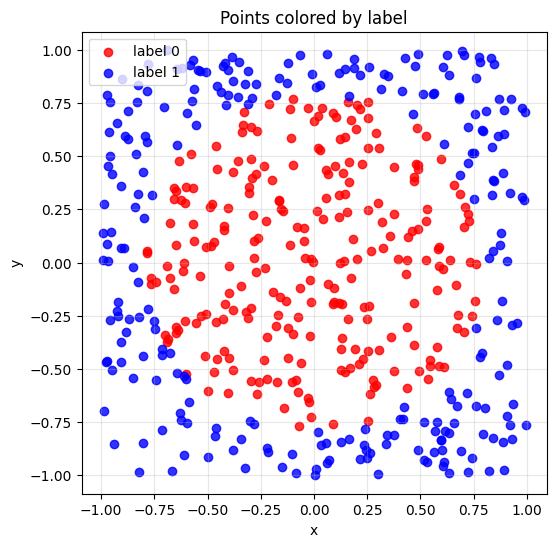

points in label 0: 252
points in label 1: 248


In [145]:
points = np.random.rand(N, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))


In [146]:
rng = np.random.default_rng(SEED)

indices   = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - TEST_SIZE))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


X_train: (400, 2) y_train: (400,)
X_test : (100, 2) y_test : (100,)


In [147]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [148]:
def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(RC):
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [149]:
theta = [[1, 1, 1] for _ in range(RC)]
omega = [[1, 1, 1] for _ in range(RC)]
qc = create_circuit(X_train[0], theta, omega)
qc.draw()


┌────────────────────┐┌────────────────────┐┌────────────────────┐»
     q: ┤ U(1.3551,1.1234,1) ├┤ U(1.3551,1.1234,1) ├┤ U(1.3551,1.1234,1) ├»
        └────────────────────┘└────────────────────┘└────────────────────┘»
meas: 1/══════════════════════════════════════════════════════════════════»
                                                                          »
«        ┌────────────────────┐ ░ ┌─┐
«     q: ┤ U(1.3551,1.1234,1) ├─░─┤M├
«        └────────────────────┘ ░ └╥┘
«meas: 1/══════════════════════════╩═
«                                  0

In [150]:
def build_simulator():
    if USE_NOISE:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 1), ['u'])
        return AerSimulator(noise_model=nm)
    return StatevectorSimulator()

sv_sim = build_simulator()

def get_probs_batch(circuits):
    """
    Returns a list of (p0, p1) for each circuit.
    Noiseless: exact statevector amplitudes.
    Noisy:     shot-based counts normalised by SHOTS.
    """
    if USE_NOISE:
        meas = [c.copy() for c in circuits]
        for c in meas:
            c.measure_all()
        compiled = transpile(meas, sv_sim)
        results  = sv_sim.run(compiled, shots=SHOTS).result()
        return [
            (results.get_counts(i).get('0', 0) / SHOTS,
             results.get_counts(i).get('1', 0) / SHOTS)
            for i in range(len(meas))
        ]
    else:
        compiled = transpile(circuits, sv_sim)
        results  = sv_sim.run(compiled).result()
        return [
            (float(np.abs(results.get_statevector(i).data[0])**2),
             float(np.abs(results.get_statevector(i).data[1])**2))
            for i in range(len(circuits))
        ]


In [151]:
def cost_function_weighted(params, X_train, y_train):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]   # alpha_0, alpha_1

    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    probs    = get_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        f0, f1     = probs[i]
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]
        total_cost += (alphas[0] * f0 - y_expected[0])**2
        total_cost += (alphas[1] * f1 - y_expected[1])**2

    return 0.5 * (total_cost / len(y_train))


In [152]:
def unpack_params(params):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]
    return theta, omega, alphas

def optimize_parameters(X_train, y_train):
    rng  = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC + 2)

    cache = {"cost": None}
    cost_history = []
    step = {"k": 0}

    def objective(params):
        cost = cost_function_weighted(params, X_train, y_train)
        cache["cost"] = cost
        return cost

    def cb(xk):
        step["k"] += 1
        cost_history.append(cache["cost"])
        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")

    res = minimize(objective, init, method="COBYLA",
                   callback=cb, options={"maxiter": MAXITER})

    theta_opt, omega_opt, _ = unpack_params(res.x)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res, cost_history


In [153]:
def predict_batch(X, theta, omega):
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs    = get_probs_batch(circuits)
    return np.array([0 if p0 >= 0.5 else 1 for p0, _ in probs])

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred    = predict_batch(X, theta, omega)
    tp        = np.sum((y_pred == positive_label) & (y == positive_label))
    fp        = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy  = np.mean(y_pred == y)
    return precision, accuracy, y_pred

# --- train + test ---
theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train)
precision_test, accuracy_test, y_pred   = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:",   precision_test)
print("Test accuracy: ",   accuracy_test)


Step 001 | cost = 1.328877
Step 002 | cost = 1.308857
Step 003 | cost = 1.419709
Step 004 | cost = 1.308857
Step 005 | cost = 1.113930
Step 006 | cost = 1.140260
Step 007 | cost = 1.400255
Step 008 | cost = 0.998525
Step 009 | cost = 1.267837
Step 010 | cost = 0.988871
Step 011 | cost = 0.940533
Step 012 | cost = 0.940533
Step 013 | cost = 1.170334
Step 014 | cost = 1.103239
Step 015 | cost = 1.002470
Step 016 | cost = 0.940533
Step 017 | cost = 0.931871
Step 018 | cost = 0.705819
Step 019 | cost = 0.705819
Step 020 | cost = 0.654291
Step 021 | cost = 0.714256
Step 022 | cost = 0.654291
Step 023 | cost = 0.897944
Step 024 | cost = 0.654291
Step 025 | cost = 0.654291
Step 026 | cost = 0.990286
Step 027 | cost = 1.314500
Step 028 | cost = 0.583071
Step 029 | cost = 0.646222
Step 030 | cost = 0.426902
Step 031 | cost = 0.348310
Step 032 | cost = 0.300156
Step 033 | cost = 0.326326
Step 034 | cost = 0.295907
Step 035 | cost = 0.320621
Step 036 | cost = 0.391469
Step 037 | cost = 0.331898
S

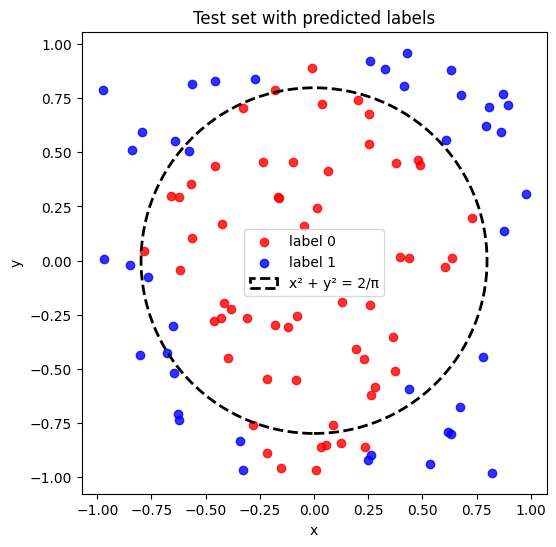

In [154]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
r = np.sqrt(2 / np.pi)
circle = plt.Circle((0, 0), r, color="black", fill=False, linestyle="--", linewidth=2, label="x² + y² = 2/π")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Test set with predicted labels")
plt.legend()
plt.show()

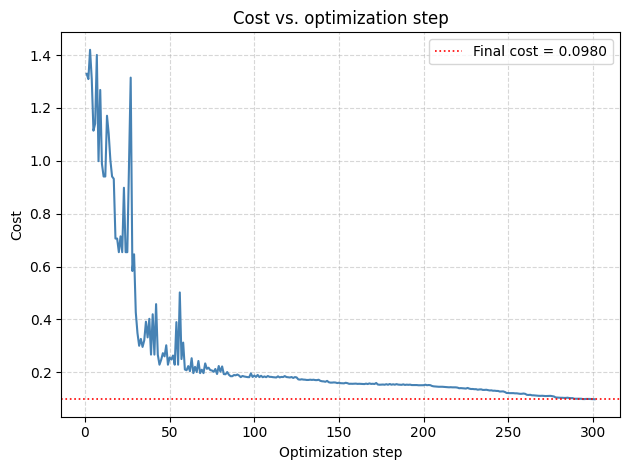

In [155]:
ax1 = plt.subplot(1, 1, 1)
ax1.plot(range(1, len(cost_history) + 1), cost_history, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Cost vs. optimization step")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.axhline(res.fun, color="red", linestyle=":", linewidth=1.2, label=f"Final cost = {res.fun:.4f}")
ax1.legend()


plt.tight_layout()
plt.show()
